# Air precleaner trial - data analysis.

In [9]:
# loading the data into memory

#importing libraries
import pandas as pd
import dask.dataframe as dd
from dask.diagnostics import ProgressBar

path=r'P:\Mine Maintenance\01 - Pre-PM Inspections by Unit #\Pre-Cleaner trial 2021'

HT2336_raw=dd.read_csv(path+'\HT2336_mts_edi_data_recording_data_2021*.csv',dtype={'value':'float64','ParameterName':'category'},usecols={'Timestamp','ParameterName','value','unit_abbr'})
HT2321_raw=dd.read_csv(path+'\HT2321_mts_edi_data_recording_data_2021*.csv',dtype={'value':'float64','ParameterName':'category'},usecols={'Timestamp','ParameterName','value','unit_abbr'})
# create a short to long version of the dataset. The ParameterName (ie Drive Motor Power) become columns with timestamp as index.

HT2336_raw['ParameterName']=HT2336_raw['ParameterName'].astype('category')
HT2321_raw['ParameterName']=HT2321_raw['ParameterName'].astype('category')

HT2336_raw['ParameterName']=HT2336_raw['ParameterName'].cat.as_known()
HT2321_raw['ParameterName']=HT2321_raw['ParameterName'].cat.as_known()

HT2336=HT2336_raw.pivot_table(index='Timestamp',columns='ParameterName',values='value')
HT2321=HT2321_raw.pivot_table(index='Timestamp',columns='ParameterName',values='value')

# Data analysis - Statistical test

At this point we will move towards identifying if there are any significant differences between the trial truck and a regular truck. Both trucks have similar ages, are running in a similar environment, share similar routes and payload. From all this similarities if there's a statistical significant difference between a regular truck and a truck running with a Mammoth precleaner we could find it through a T-test. 

The statistical test will help us see if there's a difference; not to explain causality, in other words what explains the differences. In addittion, if we can find a difference we will see which measured variables show the most change and from here on, follow up studies or literature review can help establish/explain causality.

Finally, the T-test establishes a statistical fact, a fact about the process that generated the data.

### Stating the hypothesis:

H0: HT2336-HT2321=0
This hypothesis is about no difference between chosen variables. In other words there is no difference between a truck that is running a precleaner and one that doesn't between the chosen variables.

H1: HT2336-HT2321 !=0
This alternative hypothesis states that the difference is non-zero, thus a difference exists between chosen variables and the trial vehicles. The other two hurdles at this point will be to identify the level of *statistical* significance and then **practical** significance.

We will test accross the following variables:

1. Engine Load Factor
2. Fuel Consumption Rate
3. Engine Speed
4. Drive Motor Power
5. Right Exhaust Temperature
6. Intake Manifold Air Temperature

Additional variables are captured in the dataset but not tested.

### A note on normality 
Given the size of the dataset >20GB as of 1/27/2022 I will skip  performing tests for normality. Although it is a usually a good practice to verify before applying tests that depend on this assumption for reliable results. The size of the dataset can preclude the need as a key distinction in their application focuses on applying these test when datasets are small(er). 

### T-test for differences : Fuel burn

#### Hypothesis:
**NULL** : There is no difference in average fuel burn between a HT running with an air precleaner and one that doesn't.
**Alternative hypothesis** : There is a degree of difference in average fuel burn between vehicles with and without an air precleaner unit.

#### Calculating test statistics:


In [11]:
import numpy as np
#import statsmodel.api as sm
import scipy.stats.distributions as dist

### Formulas
SE=np.sqrt((FCR_2336_std**2)/len(FCR_2336)+(FCR_2321_std**2)/len(FCR_2321))

FCR2336_mean=FCR_2336.mean()
FCR2321_mean=FCR_2321.mean()

statistic=(FCR2336_mean-FCR2321_mean)/SE
p_value=2*dist.norm.cdf(-np.abs(statistic))
p_value.compute()

# T-test for differences : 

Showing one of the dataframes after manipulation:

In [23]:
display(HT2336.compute())

ParameterName,Engine Load Factor,Engine Speed,Fuel Consumption Rate,Intake Manifold #2 Air Temperature,Intake Manifold Air Temperature,Left Exhaust Temperature,Right Exhaust Temperature,Drive Motor Power,Requested Drive Motor Torque - Motor Ctrl #1,Requested Drive Motor Torque - Motor Ctrl #2,Requested Drive Motor Torque - Trans Ctrl
Timestamp,,,,,,,,,,,
2021-07-31 09:15:50 PM,0.0,0.0,0.000000,72.320001,72.500001,122.0,122.0,0.000000,0.000000,0.000000,0.000000
2021-07-31 09:15:51 PM,0.0,0.0,0.000000,72.320001,72.500001,122.0,122.0,0.000000,0.000000,0.000000,0.000000
2021-07-31 09:15:52 PM,0.0,0.0,0.000000,72.320001,72.500001,122.0,122.0,0.000000,0.000000,0.000000,0.000000
2021-07-31 09:15:53 PM,0.0,0.0,0.000000,72.320001,72.500001,122.0,122.0,0.000000,0.000000,0.000000,0.000000
2021-07-31 09:15:54 PM,0.0,0.0,0.000000,72.320001,72.500001,122.0,122.0,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
2021-12-31 12:59:57 PM,100.0,1789.0,144.145483,101.660001,107.060001,1209.2,1167.8,122.502370,13726.031601,-13866.168410,27452.063203
2021-12-31 12:59:58 AM,18.0,1145.0,12.191540,79.880001,89.060001,615.2,620.6,-770.417202,-2522.462551,2315.945149,-4631.890299
2021-12-31 12:59:58 PM,100.0,1787.0,143.960563,101.660001,107.060001,1207.4,1166.0,125.854925,13718.655980,-13792.412195,27437.311960


In [20]:
print(HT2336.columns)

CategoricalIndex(['Engine Load Factor', 'Engine Speed',
                  'Fuel Consumption Rate',
                  'Intake Manifold #2 Air Temperature',
                  'Intake Manifold Air Temperature',
                  'Left Exhaust Temperature', 'Right Exhaust Temperature',
                  'Drive Motor Power',
                  'Requested Drive Motor Torque - Motor Ctrl #1',
                  'Requested Drive Motor Torque - Motor Ctrl #2',
                  'Requested Drive Motor Torque - Trans Ctrl'],
                 categories=['Drive Motor Power', 'Engine Load Factor', 'Engine Speed', 'Fuel Consumption Rate', 'Intake Manifold #2 Air Temperature', 'Intake Manifold Air Temperature', 'Left Exhaust Temperature', 'Requested Drive Motor Torque - Motor Ctrl #1', ...], ordered=False, dtype='category', name='ParameterName')


## Definition and calculation

In [21]:
column_list=['Intake Manifold Air Temperature'] # adjust the column list to a list or the specific variable of interest
for columns in column_list :
    FCR_2336=HT2336[columns].dropna()
    FCR_2321=HT2321[columns].dropna()
    FCR_2336_std=FCR_2336.std()
    FCR_2321_std=FCR_2321.std()
    # standard error
    SE=np.sqrt((FCR_2336_std**2)/len(FCR_2336)+(FCR_2321_std**2)/len(FCR_2321))

    FCR2336_mean=FCR_2336.mean()
    FCR2321_mean=FCR_2321.mean()

    statistic=(FCR2336_mean-FCR2321_mean)/SE
    stat_result=statistic.compute()
    p_value=2*dist.norm.cdf(-np.abs(stat_result))
    sign_lvl =0.05
    results={'Variable':[],'Statistic':[],'P-value':[],'Result':[]}
    if p_value+p_value< sign_lvl:
        results['Variable'].append(columns)
        results['Statistic'].append(stat_result)
        results['P-value'].append(p_value)
        results['Result'].append('There is AN effect for this variable.')
    else:
        results['Variable'].append(columns)
        results['Statistic'].append(stat_result)
        results['P-value'].append(p_value)
        results['Result'].append('There is NO effect for this variable.')
print(results)

{'Variable': ['Intake Manifold Air Temperature'], 'Statistic': [-501.02431078716626], 'P-value': [0.0], 'Result': ['There is AN effect for this variable.']}


In [39]:
print("{'Variable': ['Fuel Consumption Rate'], 'Statistic': [-22.591647212685864], 'P-value': [5.235865760435607e-113], 'Result': ['There is AN effect for this variable.']}")
print("{'Variable': ['Engine Speed'], 'Statistic': [-63.908622442968884], 'P-value': [0.0], 'Result': ['There is AN effect for this variable.']}")
print("{'Variable': ['Engine Load Factor'], 'Statistic': [-102.11587097548323], 'P-value': [0.0], 'Result': ['There is AN effect for this variable.']}")
print("{'Variable': ['Drive Motor Power'], 'Statistic': [313.7911284449386], 'P-value': [0.0], 'Result': ['There is AN effect for this variable.']} ")
print("{'Variable': ['Right Exhaust Temperature'], 'Statistic': [-146.02120618781314], 'P-value': [0.0], 'Result': ['There is AN effect for this variable.']}")
print("{'Variable': ['Intake Manifold Air Temperature'], 'Statistic': [-501.02431078716626], 'P-value': [0.0], 'Result': ['There is AN effect for this variable.']}")

{'Variable': ['Fuel Consumption Rate'], 'Statistic': [-22.591647212685864], 'P-value': [5.235865760435607e-113], 'Result': ['There is AN effect for this variable.']}
{'Variable': ['Engine Speed'], 'Statistic': [-63.908622442968884], 'P-value': [0.0], 'Result': ['There is AN effect for this variable.']}
{'Variable': ['Engine Load Factor'], 'Statistic': [-102.11587097548323], 'P-value': [0.0], 'Result': ['There is AN effect for this variable.']}
{'Variable': ['Drive Motor Power'], 'Statistic': [313.7911284449386], 'P-value': [0.0], 'Result': ['There is AN effect for this variable.']} 
{'Variable': ['Right Exhaust Temperature'], 'Statistic': [-146.02120618781314], 'P-value': [0.0], 'Result': ['There is AN effect for this variable.']}
{'Variable': ['Intake Manifold Air Temperature'], 'Statistic': [-501.02431078716626], 'P-value': [0.0], 'Result': ['There is AN effect for this variable.']}


## Commentary on results
The t-test over the VIMS acquired data was able to identify a significant difference in the variables of interest . Thus we are able to proceed to determine effect sizes.

# Effect sizes 

## Definition and calculation
Now we proceed to calculate the effect size by means of " Cohen's d " measure , the way it proceeds is by taking the difference in means of variables of interest divided by a  pooled sample standard deviation.

The range of values for "Cohen's d" :

 
* Small size effect d=0.020
* Medium effect size d=0.50
* Large Effect size d=0.80

So for calculating this effect size measure:

d= (mean1-mean2)/s

s = sqrt(((n1 - 1) . s1^2 + (n2 - 1) . s2^2) / (n1 + n2 - 2))

In [26]:
column_list=['Fuel Consumption Rate','Engine Speed','Engine Load Factor','Drive Motor Power','Right Exhaust Temperature','Intake Manifold Air Temperature']
for column in column_list:
    col_2336=HT2336[column].dropna()
    col_2321=HT2321[column].dropna()
    size_2336=len(col_2336)
    size_2321=len(col_2321)
    s=np.sqrt(((size_2336 - 1) * (col_2336.std())**2 + (size_2321 - 1) * (col_2321.std())**2) / (size_2336 + size_2321 - 2))
    cohen_d=(col_2336.mean()-col_2321.mean())/s
    print('The effect size for:{} is : {}'.format(column,cohen_d.compute()))

The effect size for:Fuel Consumption Rate is : -0.010223877478080325
The effect size for:Engine Speed is : -0.02895331156201205
The effect size for:Engine Load Factor is : -0.04631746489336811
The effect size for:Drive Motor Power is : 0.14209059818982744
The effect size for:Right Exhaust Temperature is : -0.06600708419413749
The effect size for:Intake Manifold Air Temperature is : -0.2285353249705688


## Commentary on the prior result

All the calculated effect sizes by Cohen's D measure resulted in "small" size effects. In more detail negative (reduced) use of fuel consumption, engine speed, engine load and intake/exhaust temperatures were found between our trial truck equipped with the precleaner vs truck with no precleaner. In addition the other small but increased measures were motor power. 

Taking the results from both test ; t-test for significance and Cohen's D for effect size we can say the following about the performance differences and enhancements brought upon by having a precleaner installed in an off-road vehicle. By these measures the truck will perform differently than a truck *without* a pre-cleaner, with any enhancements on fuel consumption rate, engine speed, load factor ,motor power , intake/exhaust temperatures of small magnitude.

With regards to air precleaner effect on system  cleanliness due to less dirt through the intakes as well as reduced consumption of air filters these effects are treated in the next section.

# Air precleaner effect on system cleanliness and air filter consumption.

The oil samples taken every scheduled PM allowed us to track the level of 'dirt ingestion' into the engines for the trialed trucks (2336/2321).

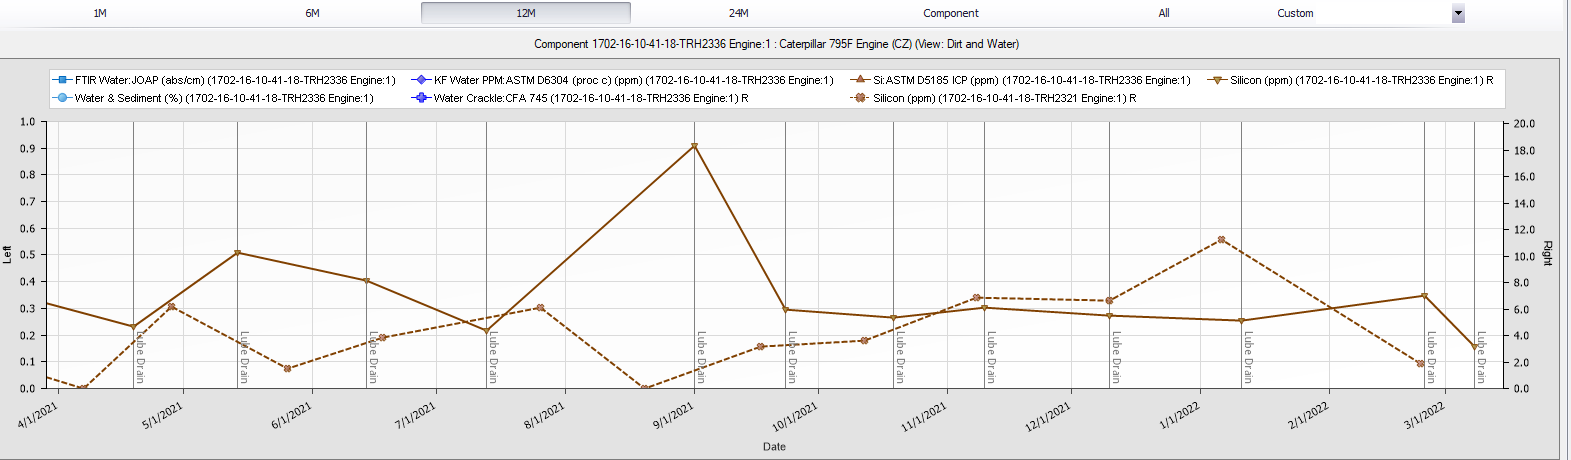

❗**image taken from Dingo Trakka oil trends**

From the image above we had a rather high silica (Si) level between mid July and early September and this event matches an engine change around this time with the sample reflecting break in wear in the new engine. Prior to this ; middle spring and most of the summer the silicon levels were higher on this truck than on 2321, and from October on we can see a flat silica profile into 2022. A confounding factor for these 3rd and 4th quarter readings as of the effect of the precleaner were reduced dust levels as operations transition to a wetter/colder weather.




## Air precleaner effect on air filter consumption 

The data were recorded on two occassions and reflected on the table below 

| Truck | New filter | Left AF | Right AF | Date | Collector | Part # | Wg Units |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 2321 | 11.20,11.13.14x2 | 13.68,13.74 | 15.40,13.56,13.51 | 8/17 1:49 | Nelson M | 419-9162 | kg  |
| 2336 | X   | 33.44,45.02 | 29.72,40.06 | 8/28 1:00 | Jerry B. | 419-9162 | Lbs |

A significance and effect size measures are performed next:

In [40]:
New_filter=[11.20,11.13,13.14,13.14]

AF_2321=[13.68,13.74,15.40,13.56,13.51]
# values in table above are reflected in lbs , they are changed into Kg to keep units consistent
AF_2336=[i/2.2 for i in [33.44,45.02,29.72,40.06]]

AF_SE=np.sqrt((np.std(AF_2336)**2)/len(AF_2336)+(np.std(AF_2321)**2)/len(AF_2321))
statistic=(np.mean(AF_2336)-np.mean(AF_2321))/AF_SE
AF_pvalue=2*dist.norm.cdf(-np.abs(statistic))
sign_lvl =0.05

if AF_pvalue+AF_pvalue<sign_lvl:
    print('There is an effect on filter weight',AF_p_value)
else:
    print('There is NO effect on filter weight')

There is NO effect on filter weight


Given that no effect was found on filter weights we will not proceed with effect size measures. A factor that could influence the results is additional data by collecting filter weights during PM times. As the sample size for both trucks is much less than 30 samples.

# Conclusion 

This comparative trial was performed to help inform our maintenance division about the capability of air precleaners provided by Mammoth Inc. to provide cost savings from :
1. Air filter consumption.
2. Fuel consumption.
3. Less oil changes as measured from particulate ingestion (Silica).

Data to answer the above was gathered through :
1. Direct measure of air filters weights during preventative maintenance.
2. VIMS measurements on engine performance that were uploaded through a telemetry solution.
3. Oil sample data gathered during scheduled preventative maintenance.

The significance and effect size test on engine performance data (VIMS) showed a difference but small effect size. Please refer to  section 4.1-4.2 .
The significance test to answer potential filter savings showed that there was no difference.**The author suggests additional measurements as the sample size is rather small and this may not allow the t-test to identify a difference.**
Oil sample data looking at indicators of dirt ingestion through Si readings (in ppm) identified a flat and low trend (no alarm) for the period of the trial (middle - late summer) into the wetter and colder months. The relative stability (flat line) with no swings is an indication of the precleaner not allowing dirt ingression. Furthermore when compared qualitatively with several other trucks in the fleet with no precleaner the level of silica during this period of the year were mostly low with a few exceptions towards end of year.





In [ ]:
# Prepared by : Nelson Martinez. , M.Eng, CRE.
# Date : 4/26/2022.
# Cortez District Open Pit division / Reliability Engineering.